In [17]:
# Cell 1: Setup and Library Imports

# Import libraries for data processing, visualization, and machine learning
# - pandas: For DataFrame operations (loading CSVs in Cell 2)
# - numpy: For numerical computations (replacing infinites in Cell 4)
# - matplotlib, seaborn: For plotting (histograms, heatmap in Cell 6)
# - sklearn.preprocessing: For StandardScaler (data scaling, may be used later)
# - sklearn.model_selection: For train_test_split (data splitting, may be used later)
# - imblearn.over_sampling: For SMOTE (class balancing, may be used later)
# - tensorflow: For neural network models (matches Colab version 2.18.0, may be used in later cells)
# - os: For file path operations (local paths in Cell 2)
# - warnings: To suppress non-critical warnings for cleaner output
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
import tensorflow as tf
import os
import warnings
import joblib
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Verify TensorFlow version to ensure compatibility
# - Should be 2.18.0, matching Colab setup
# - Confirms resolution of msvcp140_1.dll error
print("TensorFlow Version:", tf.__version__)

# Check GPU availability
# - Expect [] for CPU-only setup (like Colab, no GPU configured)
# - If GPU is added later, install tensorflow-gpu and CUDA/cuDNN
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Set random seed for reproducibility
# - Ensures consistent results for train_test_split, SMOTE, etc.
# - Matches Colab setup (seed 42)
np.random.seed(42)
tf.random.set_seed(42)

# Verify dataset path exists
# - Uses relative path ./CICIDS2017/ (assumes CICIDS2017 folder is in D:\Documents\Projects\DeepGuard)
# - os.path ensures Windows-compatible paths (\)
# - Raises error if folder is missing to catch issues early
dataset_path = "./CICIDS2017/"
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset path {dataset_path} does not exist. Ensure CICIDS2017 folder contains all CSVs.")
else:
    print(f"Dataset path verified: {dataset_path}")

TensorFlow Version: 2.18.0
GPU Available: []
Dataset path verified: ./CICIDS2017/


In [7]:
# Cell 2: Load and Combine Dataset

# Define dataset path and CSV files
# - Uses local path ./CICIDS2017/ (not Google Drive)
# - Lists all eight CICIDS2017 CSVs, matching Colab setup
# - os.path.join ensures Windows-compatible paths (\)
dataset_path = "./CICIDS2017/"
csv_files = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
]

# Load and combine CSVs into a single DataFrame
# - Reads each CSV with pandas, appends to a list, then concatenates
# - low_memory=False handles large files (~2.8M rows total)
# - Error handling catches missing files or parsing errors
# - Prints shape of each file for verification
dfs = []
for file in csv_files:
    try:
        df = pd.read_csv(os.path.join(dataset_path, file), low_memory=False)
        dfs.append(df)
        print(f"Loaded {file}: {df.shape}")
    except Exception as e:
        print(f"Error loading {file}: {e}")
combined_df = pd.concat(dfs, ignore_index=True)

# Display basic dataset information
# - Shape: Confirms total rows (~2.8M) and columns
# - Columns: Lists all column names for debugging (e.g., KeyError issues)
# - Sample data: Shows first few rows to verify data integrity
print("\nCombined Dataset Shape:", combined_df.shape)
print("Columns:\n", combined_df.columns.tolist())
print("\nSample Data:\n", combined_df.head())

Loaded Monday-WorkingHours.pcap_ISCX.csv: (529918, 79)
Loaded Tuesday-WorkingHours.pcap_ISCX.csv: (445909, 79)
Loaded Wednesday-workingHours.pcap_ISCX.csv: (692703, 79)
Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (170366, 79)
Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (288602, 79)
Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: (191033, 79)
Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (286467, 79)
Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (225745, 79)

Combined Dataset Shape: (2830743, 79)
Columns:
 [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Fl

In [8]:
combined_df.columns = combined_df.columns.str.strip().str.replace('�', '').str.replace(' ', '_').str.lower()
print("Cleaned Columns:\n", combined_df.columns.tolist())

Cleaned Columns:
 ['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min', 'fwd_packet_length_mean', 'fwd_packet_length_std', 'bwd_packet_length_max', 'bwd_packet_length_min', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_bytes/s', 'flow_packets/s', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length', 'bwd_header_length', 'fwd_packets/s', 'bwd_packets/s', 'min_packet_length', 'max_packet_length', 'packet_length_mean', 'packet_length_std', 'packet_length_variance', 'fin_flag_count', 'syn_flag_count', 'rst_flag_count', 'psh_flag_count', 'ack_flag_count', 'urg_flag_count', 'cwe_flag_count

In [9]:

combined_df = combined_df.replace([np.inf, -np.inf], np.nan)


combined_df = combined_df.dropna()
print("Shape after dropping NaN:", combined_df.shape)


combined_df = combined_df.drop_duplicates()
print("Shape after removing duplicates:", combined_df.shape)


numerical_cols = combined_df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if col in ['flow_duration', 'total_fwd_packets', 'total_backward_packets',
               'total_length_of_fwd_packets', 'total_length_of_bwd_packets']:
        invalid_rows = combined_df[combined_df[col] < 0]
        if not invalid_rows.empty:
            print(f"Found {len(invalid_rows)} rows with negative values in {col}")
            combined_df = combined_df[combined_df[col] >= 0]
print("Shape after validating numerical columns:", combined_df.shape)


for col in numerical_cols:
    non_numeric = combined_df[col].apply(lambda x: not isinstance(x, (int, float)))
    if non_numeric.any():
        print(f"Non-numeric values found in {col}:\n", combined_df[non_numeric][col].head())

Shape after dropping NaN: (2827876, 79)
Shape after removing duplicates: (2520798, 79)
Found 107 rows with negative values in flow_duration
Shape after validating numerical columns: (2520691, 79)



Unique values in 'label':
 label
BENIGN                        2094950
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Binary Label Distribution:
 binary_label
0    2094950
1     425741
Name: count, dtype: int64


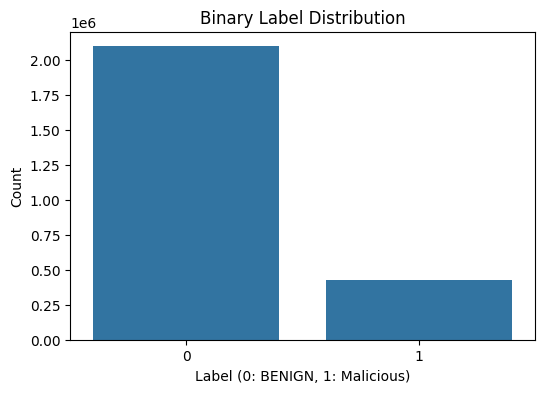

In [10]:
label_column = 'label'
print("\nUnique values in 'label':\n", combined_df[label_column].value_counts())

combined_df['binary_label'] = combined_df[label_column].apply(lambda x: 0 if x == 'BENIGN' else 1)
print("\nBinary Label Distribution:\n", combined_df['binary_label'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='binary_label', data=combined_df)
plt.title('Binary Label Distribution')
plt.xlabel('Label (0: BENIGN, 1: Malicious)')
plt.ylabel('Count')
plt.show()

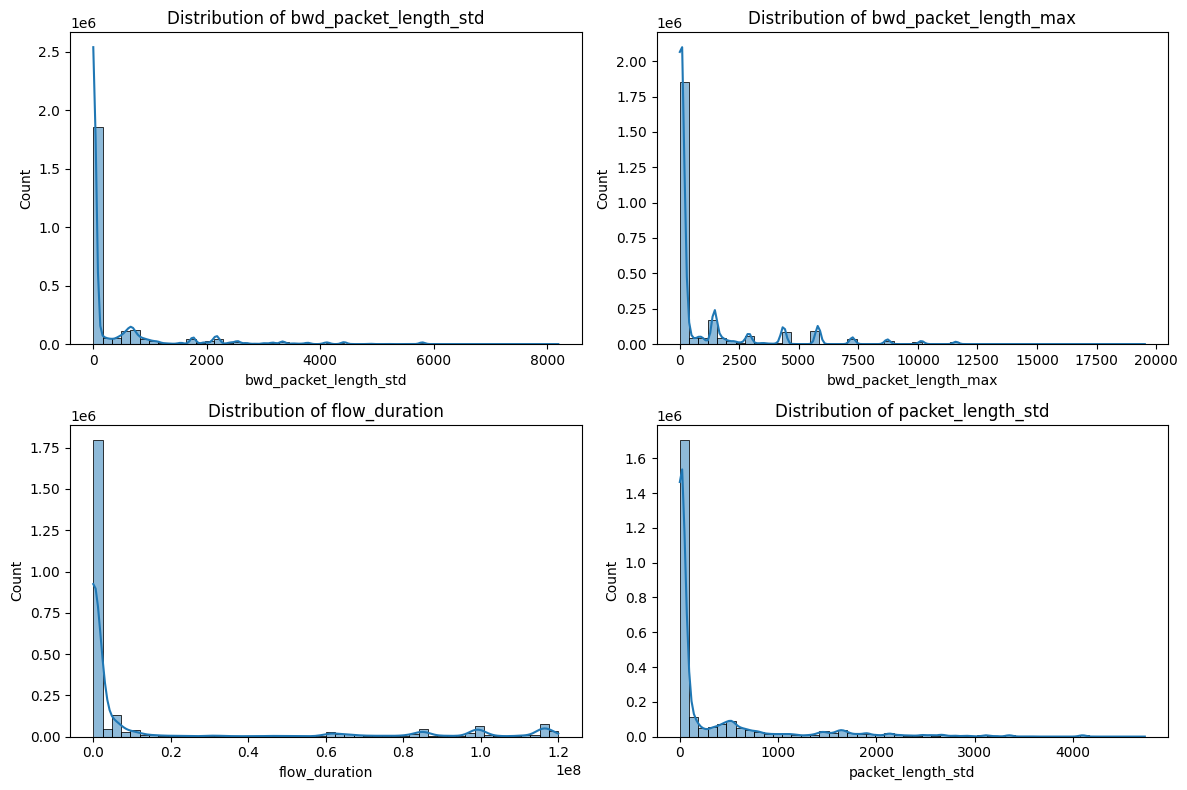

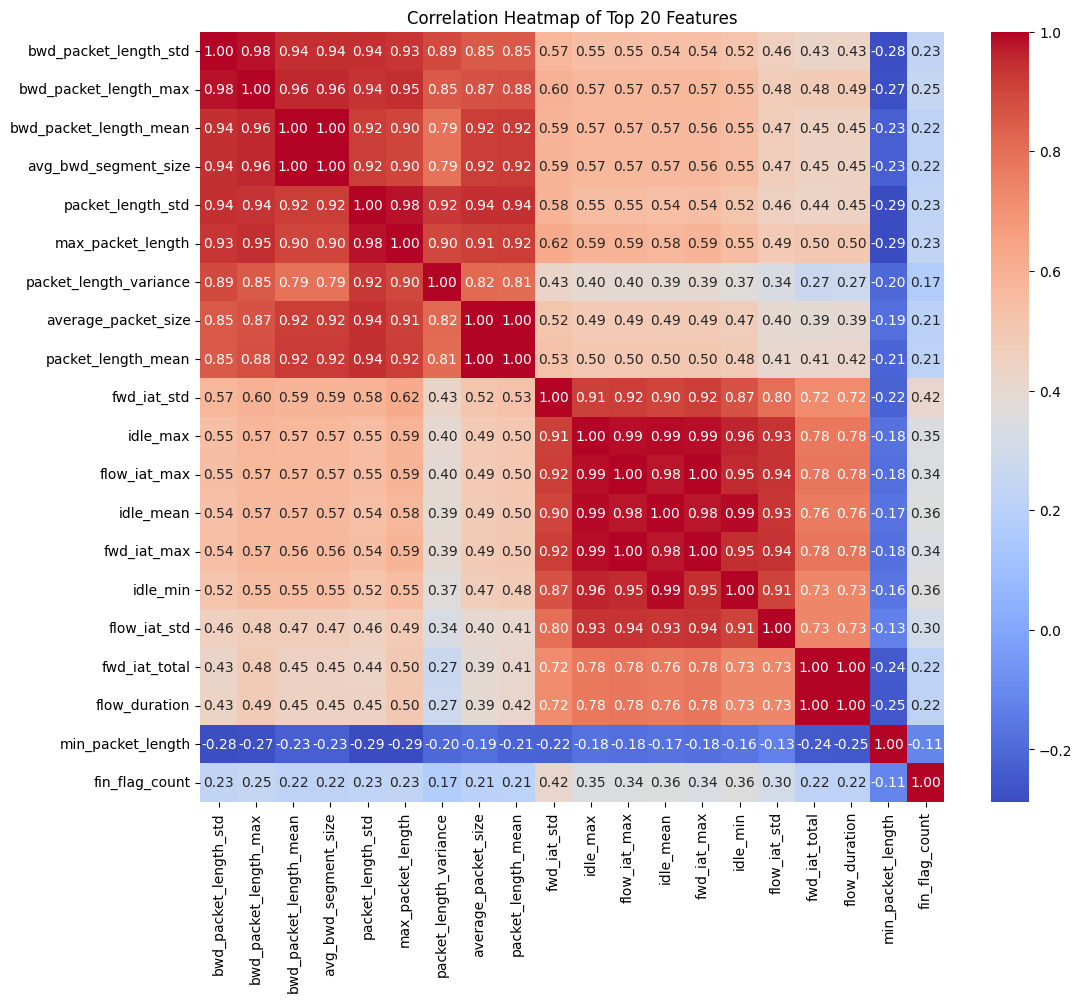

Outliers in bwd_packet_length_std: 442300
Outliers in bwd_packet_length_max: 374533
Outliers in flow_duration: 468192
Outliers in packet_length_std: 330260


In [11]:
numerical_cols = [col for col in combined_df.select_dtypes(include=[np.number]).columns if col != 'binary_label']

top_features = ['bwd_packet_length_std', 'bwd_packet_length_max', 'flow_duration', 'packet_length_std']
plt.figure(figsize=(12, 8))
for i, col in enumerate(top_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(combined_df[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

top_corr_features = combined_df[numerical_cols + ['binary_label']].corr()['binary_label'].abs().sort_values(ascending=False).index[1:21]
plt.figure(figsize=(12, 10))
sns.heatmap(combined_df[top_corr_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Top 20 Features')
plt.show()

for col in top_features:
    Q1 = combined_df[col].quantile(0.25)
    Q3 = combined_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = combined_df[(combined_df[col] < Q1 - 1.5 * IQR) | (combined_df[col] > Q3 + 1.5 * IQR)]
    print(f"Outliers in {col}: {len(outliers)}")

In [12]:
domain_features = [
    'destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets',
    'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max',
    'bwd_packet_length_max', 'flow_bytes/s', 'flow_packets/s', 'flow_iat_mean',
    'fwd_iat_total', 'bwd_iat_total', 'fwd_psh_flags', 'syn_flag_count',  
    'packet_length_mean', 'init_win_bytes_forward', 'init_win_bytes_backward',
    'act_data_pkt_fwd', 'min_seg_size_forward'
]
corr_features = combined_df[numerical_cols + ['binary_label']].corr()['binary_label'].abs().sort_values(ascending=False).index[1:21].tolist()
selected_features = list(set(domain_features + corr_features))  

missing_features = [f for f in selected_features if f not in combined_df.columns]
if missing_features:
    raise ValueError(f"Features not found in combined_df: {missing_features}")
print("\nSelected Features:\n", selected_features)

skewed_features = ['flow_duration', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets']
for col in skewed_features:
    if col in selected_features:
        combined_df[f'log_{col}'] = np.log1p(combined_df[col])  
        selected_features.append(f'log_{col}')
        selected_features.remove(col)  
print("\nUpdated Features after Transformation:\n", selected_features)

combined_df['fwd_packet_rate'] = combined_df['total_fwd_packets'] / (combined_df['flow_duration'] + 1e-6)
combined_df['bwd_packet_rate'] = combined_df['total_backward_packets'] / (combined_df['flow_duration'] + 1e-6)
selected_features.extend(['fwd_packet_rate', 'bwd_packet_rate'])
print("\nFinal Features:\n", selected_features)


Selected Features:
 ['flow_bytes/s', 'flow_duration', 'flow_packets/s', 'idle_mean', 'packet_length_mean', 'min_seg_size_forward', 'total_length_of_fwd_packets', 'flow_iat_max', 'syn_flag_count', 'destination_port', 'total_fwd_packets', 'act_data_pkt_fwd', 'bwd_packet_length_mean', 'average_packet_size', 'flow_iat_std', 'fin_flag_count', 'fwd_iat_max', 'idle_max', 'fwd_psh_flags', 'init_win_bytes_backward', 'idle_min', 'max_packet_length', 'fwd_iat_total', 'fwd_packet_length_max', 'fwd_iat_std', 'bwd_packet_length_std', 'flow_iat_mean', 'avg_bwd_segment_size', 'packet_length_std', 'total_length_of_bwd_packets', 'packet_length_variance', 'min_packet_length', 'bwd_packet_length_max', 'total_backward_packets', 'bwd_iat_total', 'init_win_bytes_forward']

Updated Features after Transformation:
 ['flow_bytes/s', 'flow_packets/s', 'idle_mean', 'packet_length_mean', 'min_seg_size_forward', 'flow_iat_max', 'syn_flag_count', 'destination_port', 'total_fwd_packets', 'act_data_pkt_fwd', 'bwd_pack

In [13]:
scaler = StandardScaler()

X = combined_df[selected_features]
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features, index=X.index)

print("\nScaled Features Statistics:\n", X_scaled_df.describe().round(2))


Scaled Features Statistics:
        flow_bytes/s  flow_packets/s   idle_mean  packet_length_mean  \
count    2520691.00      2520691.00  2520691.00          2520691.00   
mean           0.00           -0.00       -0.00                0.00   
std            1.00            1.00        1.00                1.00   
min           -0.05           -0.23       -0.38               -0.60   
25%           -0.05           -0.23       -0.38               -0.58   
50%           -0.05           -0.23       -0.38               -0.40   
75%           -0.05           -0.15       -0.38               -0.11   
max           77.89           19.55        4.45                9.88   

       min_seg_size_forward  flow_iat_max  syn_flag_count  destination_port  \
count            2520691.00    2520691.00      2520691.00        2520691.00   
mean                   0.00          0.00            0.00              0.00   
std                    1.00          1.00            1.00              1.00   
min           

In [1]:
# # Cell 10: SMOTE-Tomek for Class Balancing
# # Define target variable
# y = combined_df['binary_label']

# # Apply SMOTE-Tomek
# # - SMOTE oversamples the minority class (malicious)
# # - Tomek Links removes noisy/borderline examples for cleaner boundaries
# # - random_state=42 ensures reproducibility
# smote_tomek = SMOTETomek(random_state=42)
# X_balanced, y_balanced = smote_tomek.fit_resample(X_scaled_df, y)

# # Print shape and label distribution
# print("\nShape after SMOTE-Tomek:", X_balanced.shape)
# print("Balanced Label Distribution:\n", pd.Series(y_balanced).value_counts())

# # Visualize balanced distribution
# plt.figure(figsize=(6, 4))
# sns.countplot(x=y_balanced)
# plt.title('Balanced Label Distribution (SMOTE-Tomek)')
# plt.xlabel('Label (0: BENIGN, 1: Malicious)')
# plt.ylabel('Count')
# plt.show()


Shape after SMOTE: (4189900, 38)
Balanced Label Distribution:
 binary_label
0    2094950
1    2094950
Name: count, dtype: int64


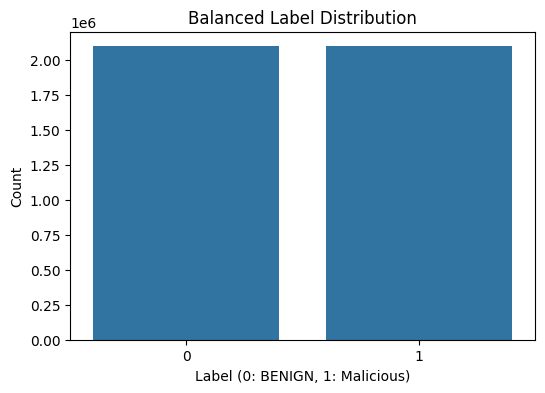

In [14]:
# SMOTE
y = combined_df['binary_label']
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_scaled_df, y)
print("\nShape after SMOTE:", X_balanced.shape)
print("Balanced Label Distribution:\n", pd.Series(y_balanced).value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_balanced)
plt.title('Balanced Label Distribution')
plt.xlabel('Label (0: BENIGN, 1: Malicious)')
plt.ylabel('Count')
plt.show()

In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(X_balanced, y_balanced, test_size=0.3, random_state=42, stratify=y_balanced)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("\nTrain Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)
print("Train Label Distribution:\n", pd.Series(y_train).value_counts())


Train Shape: (2932930, 38)
Validation Shape: (628485, 38)
Test Shape: (628485, 38)
Train Label Distribution:
 binary_label
1    1466465
0    1466465
Name: count, dtype: int64


In [18]:
pd.concat([X_train, pd.Series(y_train, name='binary_label')], axis=1).to_csv('train.csv', index=False)
pd.concat([X_val, pd.Series(y_val, name='binary_label')], axis=1).to_csv('val.csv', index=False)
pd.concat([X_test, pd.Series(y_test, name='binary_label')], axis=1).to_csv('test.csv', index=False)

joblib.dump(scaler, 'scaler.pkl')
print("Preprocessed data and scaler saved successfully.")

Preprocessed data and scaler saved successfully.
